# Import Libraries for Preprocessing, Plotting, and Modelling

In [1]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import RobustScaler
import pickle
from ipywidgets import interact, fixed

df_tweets = pd.read_csv(
    "https://raw.githubusercontent.com/SSGonda/2025ElectionsInANutshell/refs/heads/main/dataset/aggregated/X_Tweets_Filtered.csv"
)

# Preprocess Data

In [3]:
Candidates = [
    "Benhur Abalos",
    "Jerome Adonis",
    "Wilson Amad",
    "Jocelyn Andamo",
    "Bam Aquino",
    "Ronnel Arambulo",
    "Ernesto Arellano",
    "Roberto Ballon",
    "Abigail Binay",
    "Jimmy Bondoc",
    "Bong Revilla",
    "Bonifacio Bosita",
    "Arlene Brosas",
    "Roy Cabonegro",
    "Allen Capuyan",
    "Teodoro Casiño",
    "France Castro",
    "Pia Cayetano",
    "David d'Angelo",
    "Angelo de Alban",
    "Leody de Guzman",
    "Ronald dela Rosa",
    "Mimi Doringo",
    "Arnel Escobal",
    "Luke Espiritu",
    "Mody Floranda",
    "Marc Gamboa",
    "Bong Go",
    "Norberto Gonzales",
    "Jesus Hinlo Jr.",
    "Gregorio Honasan",
    "Relly Jose Jr.",
    "Panfilo Lacson",
    "Raul Lambino",
    "Lito Lapid",
    "Wilbert T. Lee",
    "Amirah Lidasan",
    "Rodante Marcoleta",
    "Imee Marcos",
    "Norman Marquez",
    "Eric Martinez",
    "Richard Mata",
    "Sonny Matula",
    "Liza Maza",
    "Heidi Mendoza",
    "Jose Montemayor Jr.",
    "Subair Mustapha",
    "Jose Olivar",
    "Willie Ong",
    "Manny Pacquiao",
    "Kiko Pangilinan",
    "Ariel Querubin",
    "Apollo Quiboloy",
    "Danilo Ramos",
    "Willie Revillame",
    "Vic Rodriguez",
    "Nur-Ana Sahidulla",
    "Phillip Salvador",
    "Tito Sotto",
    "Michael Tapado",
    "Francis Tolentino",
    "Ben Tulfo",
    "Erwin Tulfo",
    "Mar Valbuena",
    "Leandro Verceles Jr.",
    "Camille Villar",
]
Partylists = [
    "Makabayan",
    "4Ps",
    "PPP",
    "FPJ Panday Bayanihan",
    "Kabataan",
    "Duterte Youth",
    "ML",
    "PBBM",
    "P3PWD",
    "Murang Kuryente",
    "Bicol Saro",
    "Ipatupad",
    "PATROL",
    "Juan PINOY",
    "ARTE",
    "WIFI",
    "MAAGAP",
    "United Senior Citizens",
    "Epanaw Sambayanan",
    "Ako Padayon",
    "TUCP",
    "ACT Teachers",
    "1PACMAN",
    "TGP",
    "DUMPER PTDA",
    "Anakalusugan",
    "Aksyon Dapat",
    "BHW",
    "Sulong Dignidad",
    "Batang Quiapo",
    "PBA",
    "GILAS",
    "Ako Ilokano Ako",
    "Pamilyang Magsasaka",
    "Click Party",
    "Abante Bisdak",
    "Manila Teachers",
    "PAMANA",
    "Nanay",
    "KM Ngayon Na",
    "Babae Ako",
    "ARISE",
    "Magdalo",
    "APEC",
    "MAGBUBUKID",
    "SSS-GSIS Pensyonado",
    "GABRIELA",
    "Tingog",
    "APAT-DAPAT",
    "Ahon Mahirap",
    "UGB",
    "Akbayan",
    "Agimat",
    "PHILRECA",
    "Kapuso PM",
    "Ilocano Defenders",
    "1-Rider Party-list",
    "TICTOK",
    "Bayan Muna",
    "Ang Probinsyano",
    "BANAT",
    "SBP",
    "Buhay",
    "Tulungan Tayo",
    "SAGIP",
    "BTS Bayaning Tsuper",
    "Vendors",
    "ACT-CIS",
    "Aktibong Kaagapay",
    "Asenso Pinoy",
    "Solo Parents",
    "Ang Komadrona",
    "PROMDI",
    "Pusong Pinoy",
    "Kusug Tausug",
    "Damayang Filipino",
    "MPBL",
    "ANGAT",
    "Kalinga",
    "Boses Party-list",
    "Arangkada Pilipino",
    "Aangat Tayo",
    "OFW",
    "BIDA KATAGUMPAY",
    "KAMANGGAGAWA",
    "BFF",
    "Bunyog",
    "AGRI",
    "Senior Citizens",
    "4K",
    "PBP",
    "One Coop",
    "CIBAC",
    "BH - Bagong Henerasyon",
    "1AGILA",
    "EDUAKSYON",
    "Ang Tinig ng Seniors",
    "BG Party-list",
    "Pinoy Ako",
    "H.E.L.P. PILIPINAS",
    "Health Workers",
    "People's Champ",
    "AA-Kasosyo Party",
    "Solid North Party",
    "ABAMIN",
    "TRABAHO",
    "ANGKASangga",
    "TODA Aksyon",
    "Turismo",
    "Abono",
    "ASAP NA",
    "LINGAP",
    "United Frontliners",
    "Kasambahay",
    "Tutok To WIn",
    "Ako OFW",
    "AGAP",
    "1TAHANAN",
    "Coop-NATCCO",
    "KABAYAN",
    "1Munti",
    "PINOY WORKERS",
    "API Party",
    "Ako Bisaya",
    "KAMALAYAN",
    "Ako Tanod",
    "Probinsyano Ako",
    "KABABAIHAN",
    "RAM",
    "ALONA",
    "Ako Bikol",
    "GP (Galing sa Puso)",
    "KAUNLAD PINOY",
    "ABP",
    "CWS",
    "LPGMA",
    "A TEACHER",
    "SWERTE",
    "Gabay",
    "Malasakit@Bayanihan",
    "Akay ni Sol",
    "LUNAS",
    "DIWA",
    "PINUNO",
    "Pamilya Muna",
    "Bagong Pilipinas",
    "Hugpong Federal",
    "Tupad",
    "Lang Kawal",
    "Pamilya Ko",
    "BBM",
    "Heal PH",
    "Abang Lingkod",
    "MAGSASAKA",
    "Maharlika",
    "Uswag Ilonggo",
]

candidates_lowered = [candidate.lower() for candidate in Candidates]
partylists_lowered = [partylist.lower() for partylist in Partylists]

CANDIDATES = ",".join(candidates_lowered)
PARTYLISTS = ",".join(partylists_lowered)
CANDIDATE_SET = set(candidates_lowered)
PARTYLIST_SET = set(partylists_lowered)

In [4]:
df_all = pd.read_csv(
    "https://raw.githubusercontent.com/SSGonda/2025ElectionsInANutshell/refs/heads/main/dataset/aggregated/tweet_sentiments.csv"
)

df_all = df_all[df_all["tweet_id"].isin(df_tweets["Tweet ID"])]

df_all["mentioned_candidate_AI"] = df_all["mentioned_candidate_AI"].str.lower()
df_all["associated_word_AI"] = df_all["associated_word_AI"].str.lower()

# =---------------------------------------------------=
# USE THIS, Filtered DataFrames containing either only candidates or partylists, or others (not in candidates or partylists)
# =----------------------------------------------------
df_candidates = df_all[df_all["mentioned_candidate_AI"].isin(CANDIDATE_SET)]
df_partylists = df_all[df_all["mentioned_candidate_AI"].isin(PARTYLIST_SET)]
df_others = df_all[
    ~(
        (df_all["mentioned_candidate_AI"].isin(PARTYLIST_SET))
        | (df_all["mentioned_candidate_AI"].isin(CANDIDATE_SET))
    )
]

In [5]:
senate_df = pd.read_csv(
    "https://raw.githubusercontent.com/SSGonda/2025ElectionsInANutshell/refs/heads/main/dataset/raw_data/election_results/senate25-final_updated.csv"
)

name_mapping = {
    "1. ABALOS, BENHUR (PFP)": "benhur abalos",
    "2. ADONIS, JEROME (MKBYN)": "jerome adonis",
    "3. AMAD, WILSON (IND)": "wilson amad",
    "4. ANDAMO, NARS ALYN (MKBYN)": "jocelyn andamo",
    "5. AQUINO, BAM (KNP)": "bam aquino",
    "6. ARAMBULO, RONNEL (MKBYN)": "ronnel arambulo",
    "7. ARELLANO, ERNESTO (KTPNAN)": "ernesto arellano",
    "8. BALLON, ROBERTO (IND)": "roberto ballon",
    "9. BINAY, ABBY (NPC)": "abigail binay",
    "10. BONDOC, JIMMY (PDPLBN)": "jimmy bondoc",
    "11. BONG REVILLA,RAMON, JR.(LAKAS)": "bong revilla",
    "12. BOSITA, COLONEL (IND)": "bonifacio bosita",
    "13. BROSAS, ARLENE (MKBYN)": "arlene brosas",
    "14. CABONEGRO, ROY (DPP)": "roy cabonegro",
    "16. CASIÑO, TEDDY (MKBYN)": "teodoro casiño",
    "15. CAPUYAN, ALLEN (PPP)": "allen capuyan",
    "17. CASTRO, TEACHER FRANCE (MKBYN)": "france castro",
    "18. CAYETANO, PIA (NP)": "pia cayetano",
    "19. D'ANGELO, DAVID (BUNYOG)": "david d'angelo",
    "20. DE ALBAN,ATTORNEY ANGELO (IND)": "angelo de alban",
    "21. DE GUZMAN, KA LEODY (PLM)": "leody de guzman",
    "22. DELA ROSA, BATO (PDPLBN)": "ronald dela rosa",
    "23. DORINGO, NANAY MIMI (MKBYN)": "mimi doringo",
    "24. ESCOBAL, ARNEL (PM)": "arnel escobal",
    "25. ESPIRITU, LUKE (PLM)": "luke espiritu",
    "26. FLORANDA, MODY PISTON (MKBYN)": "mody floranda",
    "27. GAMBOA, MARC LOUIE (IND)": "marc gamboa",
    "28. GO, BONG GO    (PDPLBN)": "bong go",
    "29. GONZALES, NORBERTO (PDSP)": "norberto gonzales",
    "30. HINLO, JAYVEE (PDPLBN)": "jesus hinlo jr.",
    "31. HONASAN, GRINGO (RP)": "gregorio honasan",
    "32. JOSE, RELLY JR. (KBL)": "relly jose jr.",
    "33. LACSON, PING (IND)": "panfilo lacson",
    "34. LAMBINO,  RAUL  (PDPLBN)": "raul lambino",
    "35. LAPID, LITO (NPC)": "lito lapid",
    "36. LEE, MANOY WILBERT (AKSYON)": "wilbert t. lee",
    "37. LIDASAN, AMIRAH (MKBYN)": "amirah lidasan",
    "38. MARCOLETA, RODANTE (IND)": "rodante marcoleta",
    "39. MARCOS, IMEE R. (NP)": "imee marcos",
    "40. MARQUEZ, NORMAN (IND)": "norman marquez",
    "41. MARTINEZ, ERIC (IND)": "eric martinez",
    "42. MATA, DOC MARITES (IND)": "richard mata",
    "43. MATULA,  ATTY.  SONNY (WPP)": "sonny matula",
    "44. MAZA, LIZA (MKBYN)": "liza maza",
    "45. MENDOZA, HEIDI (IND)": "heidi mendoza",
    "46. MONTEMAYOR,  JOEY  (IND)": "jose montemayor jr.",
    "47. MUSTAPHA, SUBAIR (WPP)": "subair mustapha",
    "48. OLIVAR, JOSE JESSIE (IND)": "jose olivar",
    "49. ONG, DOC WILLIE (AKSYON)": "willie ong",
    "50. PACQUIAO, MANNY PACMAN (PFP)": "manny pacquiao",
    "51. PANGILINAN, KIKO (LP)": "kiko pangilinan",
    "52. QUERUBIN,  ARIEL PORFIRIO (NP)": "ariel querubin",
    "53. QUIBOLOY, APOLLO (IND)": "apollo quiboloy",
    "54. RAMOS, DANILO (MKBYN)": "danilo ramos",
    "55. REVILLAME, WILLIE WIL (IND)": "willie revillame",
    "56. RODRIGUEZ, ATTY. VIC (IND)": "vic rodriguez",
    "57. SAHIDULLA, NUR-ANA (IND)": "nur-ana sahidulla",
    "58. SALVADOR, PHILLIP IPE (PDPLBN)": "phillip salvador",
    "59. SOTTO, TITO (NPC)": "tito sotto",
    "60. TAPADO, MICHAEL BONGBONG (PM)": "michael tapado",
    "61. TOLENTINO, FRANCIS TOL (PFP)": "francis tolentino",
    "62. TULFO, BEN BITAG (IND)": "ben tulfo",
    "63. TULFO, ERWIN (LAKAS)": "erwin tulfo",
    "64. VALBUENA, MAR MANIBELA (IND)": "mar valbuena",
    "65. VERCELES, LEANDRO (IND)": "leandro verceles jr.",
    "66. VILLAR, CAMILLE (NP)": "camille villar",
}

senate_df.rename(columns=name_mapping, inplace=True)
senate_df.drop(
    columns=[
        "region",
        "province",
        "municipality",
        "barangay",
        "machineId",
        "registeredVoters",
        "actualVoters",
        "validBallot",
        "overVotes",
        "underVotes",
        "validVotes",
        "obtainedVotes",
    ],
    inplace=True,
)

senate_votes_df = (
    senate_df.sum(axis=0)
    .reset_index(name="total")
    .sort_values("total", ascending=False)
    .set_index("index")
)
senate_votes_df

,total
index,
bong go,26918348
bam aquino,20899112
ronald dela rosa,20599895
erwin tulfo,17067983
kiko pangilinan,15293385
...,...
relly jose jr.,455243
jose olivar,445618
subair mustapha,385402


In [6]:
partylist_df = pd.read_csv(
    "https://raw.githubusercontent.com/SSGonda/2025ElectionsInANutshell/refs/heads/main/dataset/raw_data/election_results/partylist25-final_updated.csv"
)

partylist_mapping = {
    "1 4PS": "4ps",
    "2 PPP": "ppp",
    "3 FPJ PANDAY BAYANIHAN": "fpj panday bayanihan",
    "4 KABATAAN": "kabataan",
    "5 DUTERTE YOUTH": "duterte youth",
    "6 ML": "ml",
    "7 PBBM": "pbbm",
    "8 P3PWD": "p3pwd",
    "9 MURANG KURYENTE": "murang kuryente",
    "10 BICOL SARO": "bicol saro",
    "11 IPATUPAD": "ipatupad",
    "12 PATROL": "patrol",
    "13 JUAN PINOY": "juan pinoy",
    "14 ARTE": "arte",
    "15 WIFI": "wifi",
    "16 MAAGAP": "maagap",
    "17 UNITED SENIOR CITIZENS": "united senior citizens",
    "18 EPANAW SAMBAYANAN": "epanaw sambayanan",
    "19 AKO PADAYON": "ako padayon",
    "20 TUCP": "tucp",
    "21 ACT TEACHERS": "act teachers",
    "22 1PACMAN": "1pacman",
    "23 TGP": "tgp",
    "24 DUMPER PTDA": "dumper ptda",
    "25 ANAKALUSUGAN": "anakalusugan",
    "26 AKSYON DAPAT": "aksyon dapat",
    "27 BHW": "bhw",
    "28 SULONG DIGNIDAD": "sulong dignidad",
    "29 BATANG QUIAPO": "batang quiapo",
    "30 PBA": "pba",
    "31 GILAS": "gilas",
    "32 AKO ILOCANO AKO": "ako ilokano ako",
    "33 PAMILYANG MAGSASAKA": "pamilyang magsasaka",
    "34 CLICK PARTY": "click party",
    "35 ABANTE BISDAK": "abante bisdak",
    "36 MANILA TEACHERS": "manila teachers",
    "37 PAMANA": "pamana",
    "38 NANAY": "nanay",
    "39 KM NGAYON NA": "km ngayon na",
    "40 BABAE AKO": "babae ako",
    "41 ARISE": "arise",
    "42 MAGDALO": "magdalo",
    "43 APEC": "apec",
    "44 MAGBUBUKID": "magbubukid",
    "45 SSS-GSIS PENSYONADO": "sss-gsis pensyonado",
    "46 GABRIELA": "gabriela",
    "47 TINGOG": "tingog",
    "48 APAT-DAPAT": "apat-dapat",
    "49 AHON MAHIRAP": "ahon mahirap",
    "50 UGB": "ugb",
    "51 AKBAYAN": "akbayan",
    "52 AGIMAT": "agimat",
    "53 PHILRECA": "philreca",
    "54 KAPUSO PM": "kapuso pm",
    "55 ILOCANO DEFENDERS": "ilocano defenders",
    "56 1-RIDER PARTY-LIST": "1-rider party-list",
    "57 TICTOK": "tictok",
    "59 BAYAN MUNA": "bayan muna",
    "60 ANG PROBINSIYANO": "ang probinsiyano",
    "61 BANAT": "banat",
    "62 SBP": "sbp",
    "63 BUHAY": "buhay",
    "64 TULUNGAN TAYO": "tulungan tayo",
    "65 SAGIP": "sagip",
    "66 BTS BAYANING TSUPER": "bts bayaning tsuper",
    "67 VENDORS": "vendors",
    "68 ACT-CIS": "act-cis",
    "69 AKTIBONG KAAGAPAY": "aktibong kaagapay",
    "70 ASENSO PINOY": "asenso pinoy",
    "71 SOLO PARENTS": "solo parents",
    "72 ANG KOMADRONA": "ang komadrona",
    "73 PROMDI": "promdi",
    "74 PUSONG PINOY": "pusong pinoy",
    "75 KUSUG TAUSUG": "kusug tausug",
    "76 DAMAYANG FILIPINO": "damayang filipino",
    "77 MPBL": "mpbl",
    "78 ANGAT": "angat",
    "79 KALINGA": "kalinga",
    "80 BOSES PARTY-LIST": "boses party-list",
    "81 ARANGKADA PILIPINO": "arangkada pilipino",
    "82 AANGAT TAYO": "aangat tayo",
    "83 OFW": "ofw",
    "84 BIDA KATAGUMPAY": "bida katagumpay",
    "85 KAMANGGAGAWA": "kamanggagawa",
    "86 BFF": "bff",
    "87 BUNYOG": "bunyog",
    "88 AGRI": "agri",
    "89 SENIOR CITIZENS": "senior citizens",
    "90 4K": "4k",
    "91 PBP": "pbp",
    "92 ONE COOP": "one coop",
    "93 CIBAC": "cibac",
    "94 BH - BAGONG HENERASYON": "bh - bagong henerasyon",
    "95 1AGILA": "1agila",
    "96 EDUAKSYON": "eduaksyon",
    "97 ANG TINIG NG SENIORS": "ang tinig ng seniors",
    "98 BG PARTY-LIST": "bg party-list",
    "99 PINOY AKO": "pinoy ako",
    "100 H.E.L.P. PILIPINAS": "h.e.l.p. pilipinas",
    "101 HEALTH WORKERS": "health workers",
    "102 PEOPLE'S CHAMP": "people's champ",
    "103 AA-KASOSYO PARTY": "aa-kasosyo party",
    "104 SOLID NORTH PARTY": "solid north party",
    "105 ABAMIN": "abamin",
    "106 TRABAHO": "trabaho",
    "107 ANGKASANGGA": "angkasangga",
    "108 TODA AKSYON": "toda aksyon",
    "109 TURISMO": "turismo",
    "110 ABONO": "abono",
    "111 ASAP NA": "asap na",
    "112 LINGAP": "lingap",
    "113 UNITED FRONTLINERS": "united frontliners",
    "114 KASAMBAHAY": "kasambahay",
    "115 TUTOK TO WIN": "tutok to win",
    "116 AKO OFW": "ako ofw",
    "117 AGAP": "agap",
    "118 1TAHANAN": "1tahanan",
    "119 COOP-NATCCO": "coop-natcco",
    "120 KABAYAN": "kabayan",
    "121 1MUNTI": "1munti",
    "122 PINOY WORKERS": "pinoy workers",
    "123 API PARTY": "api party",
    "124 AKO BISAYA": "ako bisaya",
    "125 KAMALAYAN": "kamalayan",
    "126 AKO TANOD": "ako tanod",
    "127 PROBINSYANO AKO": "probinsyano ako",
    "128 KABABAIHAN": "kababaihan",
    "129 RAM": "ram",
    "130 ALONA": "alona",
    "131 AKO BICOL": "ako bikol",
    "132 GP (GALING SA PUSO)": "gp (galing sa puso)",
    "133 KAUNLAD PINOY": "kaunlad pinoy",
    "134 ABP": "abp",
    "135 CWS": "cws",
    "136 LPGMA": "lpgma",
    "137 A TEACHER": "a teacher",
    "138 SWERTE": "swerte",
    "139 GABAY": "gabay",
    "140 MALASAKIT@BAYANIHAN": "malasakit@bayanihan",
    "141 AKAY NI SOL": "akay ni sol",
    "142 LUNAS": "lunas",
    "143 DIWA": "diwa",
    "144 PINUNO": "pinuno",
    "145 PAMILYA MUNA": "pamilya muna",
    "146 BAGONG PILIPINAS": "bagong pilipinas",
    "147 HUGPONG FEDERAL": "hugpong federal",
    "148 TUPAD": "tupad",
    "149 LAANG KAWAL": "lang kawal",
    "150 PAMILYA KO": "pamilya ko",
    "151 BBM": "bbm",
    "152 HEAL PH": "heal ph",
    "153 ABANG LINGKOD": "abang lingkod",
    "154 MAGSASAKA": "magsasaka",
    "155 MAHARLIKA": "maharlika",
    "156 USWAG ILONGGO": "uswag ilonggo",
}

partylist_df.rename(columns=partylist_mapping, inplace=True)
partylist_df.drop(
    columns=[
        "region",
        "province",
        "municipality",
        "barangay",
        "machineId",
        "registeredVoters",
        "actualVoters",
        "validBallot",
        "overVotes",
        "underVotes",
        "validVotes",
        "obtainedVotes",
    ],
    inplace=True,
)

partylist_votes_df = (
    partylist_df.sum(axis=0)
    .reset_index(name="total")
    .sort_values("total", ascending=False)
    .set_index("index")
)

partylist_votes_df

,total
index,
akbayan,2777083
duterte youth,2328166
tingog,1817668
4ps,1461585
act-cis,1238226
...,...
bida katagumpay,20784
hugpong federal,18754
arte,14132


In [7]:
df_candidates_tone = (
    df_candidates.groupby(["mentioned_candidate_AI", "tone_AI"])
    .size()
    .unstack(fill_value=0)
)
df_candidates_tone

tone_AI,Anger,Contempt,Disgust,Enjoyment,Fear,Neutral,Sadness,Surprise
mentioned_candidate_AI,,,,,,,,
abigail binay,0,1,0,0,0,2,0,0
apollo quiboloy,1,6,0,1,0,5,0,0
ariel querubin,0,0,0,0,0,1,0,0
arlene brosas,0,0,0,0,0,4,0,0
bam aquino,1,4,0,65,0,67,1,0
ben tulfo,0,0,0,1,0,3,0,0
benhur abalos,0,1,0,0,0,3,0,0
bong go,5,6,0,1,0,8,0,0
bong revilla,1,1,2,0,0,2,0,1


In [8]:
df_candidates_judgement = (
    df_candidates.groupby(["mentioned_candidate_AI", "perceived_judgement_AI"])
    .size()
    .unstack(fill_value=0)
)
df_candidates_judgement

perceived_judgement_AI,InFavor,Opposedto,Unsure
mentioned_candidate_AI,,,
abigail binay,0,1,2
apollo quiboloy,5,6,2
ariel querubin,1,0,0
arlene brosas,3,0,1
bam aquino,127,1,10
ben tulfo,2,0,2
benhur abalos,2,0,2
bong go,7,10,3
bong revilla,1,4,2


In [9]:
df_candidates_polarity = df_candidates.groupby(["mentioned_candidate_AI"])[
    "polarity_AI"
].mean()
df_candidates_polarity

mentioned_candidate_AI
abigail binay       -0.266667
apollo quiboloy     -0.084615
ariel querubin       0.500000
arlene brosas        0.375000
bam aquino           0.605072
ben tulfo            0.300000
benhur abalos        0.125000
bong go             -0.170000
bong revilla        -0.342857
camille villar      -0.242857
danilo ramos         0.520000
david d'angelo       0.400000
erwin tulfo          0.357143
france castro        0.516667
francis tolentino   -0.016667
gregorio honasan     0.000000
heidi mendoza        0.517857
imee marcos         -0.375000
jesus hinlo jr.      0.800000
jimmy bondoc         0.400000
jocelyn andamo       0.650000
kiko pangilinan      0.598013
leody de guzman      0.350000
lito lapid          -0.533333
liza maza            0.650000
luke espiritu        0.531250
manny pacquiao      -0.233333
mody floranda        0.650000
panfilo lacson       0.180000
phillip salvador    -0.166667
pia cayetano        -0.150000
raul lambino         0.800000
richard mata     

In [10]:
df_senate_in_mentioned = senate_votes_df[
    senate_votes_df.index.isin(df_candidates_tone.index)
]
df_candidates_all = (
    df_senate_in_mentioned.join(df_candidates_tone)
    .join(df_candidates_judgement)
    .join(df_candidates_polarity)
)
df_candidates_all

,total,Anger,Contempt,Disgust,Enjoyment,Fear,Neutral,Sadness,Surprise,InFavor,Opposedto,Unsure,polarity_AI
index,,,,,,,,,,,,,
bong go,26918348,5,6,0,1,0,8,0,0,7,10,3,-0.170000
bam aquino,20899112,1,4,0,65,0,67,1,0,127,1,10,0.605072
ronald dela rosa,20599895,5,1,1,1,0,5,0,0,6,5,2,-0.030769
erwin tulfo,17067983,0,0,0,0,0,7,0,0,5,0,2,0.357143
kiko pangilinan,15293385,1,5,0,71,0,73,1,0,138,2,11,0.598013
rodante marcoleta,15144044,1,1,0,1,0,0,0,0,2,0,1,0.366667
panfilo lacson,15066795,1,1,0,0,0,3,0,0,4,1,0,0.180000
tito sotto,14797756,2,2,0,1,0,8,0,0,5,4,4,-0.030769
pia cayetano,14522012,1,0,1,0,0,2,0,0,2,2,0,-0.150000


# Normalization Functions Before Plotting

In [11]:
# Normalization

# Source - https://stackoverflow.com/a
# Posted by Cina, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-01, License - CC BY-SA 4.0


def mean_normalize(df):
    return (df - df.mean()) / df.std()


def minmax_normalize(df):
    return (df - df.min()) / (df.max() - df.min())

# Plot Data, Some Light EDA

In [12]:
# Opted for mean normalization, to roughly match scaling done for modelling
df_candidates_all_normalized = mean_normalize(df_candidates_all)

fig_all = px.line(
    df_candidates_all_normalized,
    x=df_candidates_all_normalized.index,
    y=df_candidates_all_normalized.columns,
    template="plotly_dark",
)
fig_all.show()

# Fit and Evaluate the Model

In [13]:
scaler = RobustScaler()

X_all = scaler.fit_transform(
    df_candidates_all.drop("total", axis=1), df_candidates_all["total"]
)
y_all = df_candidates_all["total"]

X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y_all, random_state=360
)  # 360 is fixed for consistency and reproducability of a "good" split

In [14]:
lm = Ridge()

lm.fit(X_all_train, y_all_train)

y_pred = lm.predict(X_all_test)
r2 = r2_score(y_all_test, y_pred)
print(r2)

lm.coef_

0.6376646934020613


array([ 4021873.64784945,  2845685.98057253,   113480.54570346,
       -1299257.39254767, -1304994.77216988,   234666.86415766,
       -1256397.31065332,  1812027.85988681,  2298433.15092579,
       -3946308.20501198,  3737161.25909956, -2372043.60230419])

###Coefficients


In [15]:
coef_df = pd.DataFrame(
    {"Feature": df_candidates_all.columns[1:], "Coefficient": lm.coef_}
).sort_values(by="Coefficient", ascending=False)

In [16]:
print("Coefficients (Candidates):")
coef_df

Coefficients (Candidates):


,Feature,Coefficient
0,Anger,4.021874e+06
10,Unsure,3.737161e+06
1,Contempt,2.845686e+06
8,InFavor,2.298433e+06
7,Surprise,1.812028e+06
5,Neutral,2.346669e+05
2,Disgust,1.134805e+05
6,Sadness,-1.256397e+06
3,Enjoyment,-1.299257e+06
4,Fear,-1.304995e+06


###Plots

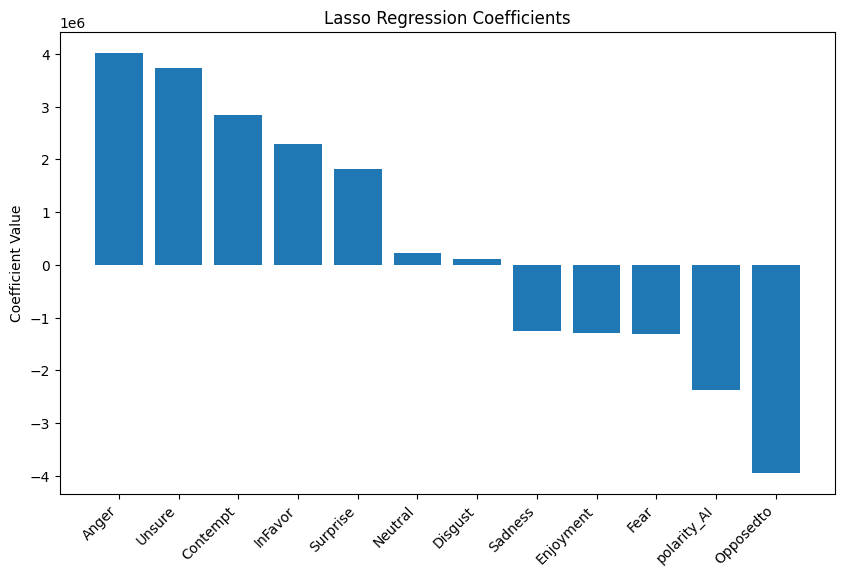

In [17]:
plt.figure(figsize=(10, 6))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")
plt.show()

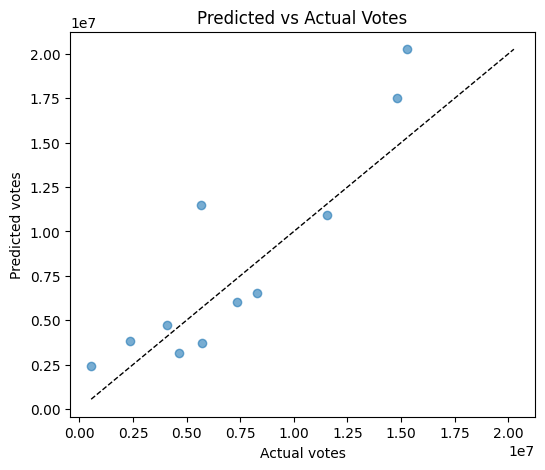

R²: 0.6376646934020613


In [18]:
y_pred = lm.predict(X_all_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_all_test, y_pred, alpha=0.6)
lims = [min(y_all_test.min(), y_pred.min()), max(y_all_test.max(), y_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual votes")
plt.ylabel("Predicted votes")
plt.title("Predicted vs Actual Votes")
plt.show()

r2 = r2_score(y_all_test, y_pred)
print("R²:", r2)

# Make a Sample Prediction

In [19]:
# Heidi Mendoza
# out of a sample of 1000 tweets,
# 2  2  1  25  1  25  0  0  47  4  5  0.517857

ANGER = 2
CONTEMPT = 2
DISGUST = 1
ENJOYMENT = 25
FEAR = 1
NEUTRAL = 25
SADNESS = 0
SURPRISE = 0
INFAVOR = 47
OPPOSEDTO = 4
UNSURE = 5
POLARITY_AI = 0.517857


sample_df_all = pd.DataFrame(
    [
        [
            ANGER,
            CONTEMPT,
            DISGUST,
            ENJOYMENT,
            FEAR,
            NEUTRAL,
            SADNESS,
            SURPRISE,
            INFAVOR,
            OPPOSEDTO,
            UNSURE,
            POLARITY_AI,
        ]
    ],
    columns=df_candidates_all.columns[1:],
)

sample_scaled = scaler.transform(sample_df_all)

predicted_votes_all = lm.predict(sample_scaled)

actual_votes = senate_votes_df.loc["heidi mendoza", "total"]
predicted_votes = predicted_votes_all[0]

comparison_df = pd.DataFrame(
    {
        "Candidate": ["Heidi Mendoza"],
        "Actual Votes": [actual_votes],
        "Predicted Votes": [predicted_votes],
        "Difference": [predicted_votes - actual_votes],
    }
)

comparison_df

,Candidate,Actual Votes,Predicted Votes,Difference
0,Heidi Mendoza,8743925,1.004892e+07,1.304995e+06


In [20]:
def model_predict(
    lm: Ridge,
    ANGER: int,
    CONTEMPT: int,
    DISGUST: int,
    ENJOYMENT: int,
    FEAR: int,
    NEUTRAL: int,
    SADNESS: int,
    SURPRISE: int,
    INFAVOR: int,
    OPPOSEDTO: int,
    UNSURE: int,
    POLARITY_AI: float,
):
    sample_df_all = pd.DataFrame(
        [
            [
                ANGER,
                CONTEMPT,
                DISGUST,
                ENJOYMENT,
                FEAR,
                NEUTRAL,
                SADNESS,
                SURPRISE,
                INFAVOR,
                OPPOSEDTO,
                UNSURE,
                POLARITY_AI,
            ]
        ],
        columns=df_candidates_all.columns[1:],
    )

    sample_scaled = scaler.transform(sample_df_all)

    predicted_votes_all = lm.predict(sample_scaled)

    return predicted_votes_all[0]

In [21]:
interact(
    model_predict,
    lm=fixed(lm),
    ANGER=(0, 200, 1),
    CONTEMPT=(0, 200, 1),
    DISGUST=(0, 200, 1),
    ENJOYMENT=(0, 200, 1),
    FEAR=(0, 200, 1),
    NEUTRAL=(0, 200, 1),
    SADNESS=(0, 200, 1),
    SURPRISE=(0, 200, 1),
    INFAVOR=(0, 200, 1),
    OPPOSEDTO=(0, 200, 1),
    UNSURE=(0, 200, 1),
    POLARITY_AI=(-1.0, 1.0, 0.05),
);

interactive(children=(IntSlider(value=100, description='ANGER', max=200), IntSlider(value=100, description='CO…

# Partylists


## Preprocess

In [22]:
df_partylists_tone = (
    df_partylists.groupby(["mentioned_candidate_AI", "tone_AI"])
    .size()
    .unstack(fill_value=0)
)
df_partylists_tone

tone_AI,Anger,Contempt,Disgust,Enjoyment,Neutral
mentioned_candidate_AI,,,,,
4ps,0,1,0,0,2
act teachers,0,0,0,2,1
act-cis,0,0,0,0,3
agri,0,0,0,0,1
akbayan,0,0,0,3,9
bayan muna,1,0,0,2,4
bbm,0,1,0,1,7
duterte youth,19,17,1,6,12
gabriela,1,0,0,7,2


In [23]:
df_partylists_judgement = (
    df_partylists.groupby(["mentioned_candidate_AI", "perceived_judgement_AI"])
    .size()
    .unstack(fill_value=0)
)

df_partylists_judgement

perceived_judgement_AI,InFavor,Opposedto,Unsure
mentioned_candidate_AI,,,
4ps,2,1,0
act teachers,3,0,0
act-cis,2,0,1
agri,0,0,1
akbayan,12,0,0
bayan muna,4,1,2
bbm,4,0,5
duterte youth,16,36,3
gabriela,9,1,0


In [24]:
df_partylists_polarity = df_partylists.groupby(["mentioned_candidate_AI"])[
    "polarity_AI"
].mean()

df_partylists_polarity

mentioned_candidate_AI
4ps                    0.066667
act teachers           0.700000
act-cis                0.333333
agri                   0.200000
akbayan                0.575000
bayan muna             0.242857
bbm                    0.277778
duterte youth         -0.310909
gabriela               0.580000
health workers         0.800000
ipatupad               0.500000
kabataan               0.612500
kabayan                0.500000
magdalo                0.500000
makabayan              0.525000
malasakit@bayanihan    0.500000
ml                     0.531579
p3pwd                  0.500000
patrol                 0.575000
pba                    0.000000
pbbm                  -0.640000
tupad                 -0.800000
Name: polarity_AI, dtype: float64

In [25]:
df_party_in_mentioned = partylist_votes_df[
    partylist_votes_df.index.isin(df_partylists_tone.index)
]
df_partylists_all = (
    df_party_in_mentioned.join(df_partylists_tone)
    .join(df_partylists_judgement)
    .join(df_partylists_polarity)
)

df_partylists_all

,total,Anger,Contempt,Disgust,Enjoyment,Neutral,InFavor,Opposedto,Unsure,polarity_AI
index,,,,,,,,,,
akbayan,2777083,0,0,0,3,9,12,0,0,0.575000
duterte youth,2328166,19,17,1,6,12,16,36,3,-0.310909
4ps,1461585,0,1,0,0,2,2,1,0,0.066667
act-cis,1238226,0,0,0,0,3,2,0,1,0.333333
malasakit@bayanihan,575584,0,0,0,0,1,1,0,0,0.500000
ml,546805,0,1,0,7,11,17,1,1,0.531579
act teachers,353173,0,0,0,2,1,3,0,0,0.700000
kabataan,311762,0,0,0,4,4,8,0,0,0.612500
gabriela,256612,1,0,0,7,2,9,1,0,0.580000


In [26]:
df_partylists_all_normalized = mean_normalize(df_partylists_all)

fig_all = px.line(
    df_partylists_all_normalized,
    x=df_partylists_all_normalized.index,
    y=df_partylists_all_normalized.columns,
    template="plotly_dark",
)
fig_all.show()

##Fit and Model

In [27]:
scaler_p = RobustScaler()

X_all_p = scaler_p.fit_transform(
    df_partylists_all.drop("total", axis=1), df_partylists_all["total"]
)
y_all_p = df_partylists_all["total"]

X_all_train_p, X_all_test_p, y_all_train_p, y_all_test_p = train_test_split(
    X_all_p, y_all_p, random_state=360
)  # random state is set for consistency and reproducibility of a "good" split

In [28]:
lm_p = Ridge()

lm_p.fit(X_all_train_p, y_all_train_p)

y_pred_p = lm_p.predict(X_all_test_p)
r2_p = r2_score(y_all_test_p, y_pred_p)
print(r2_p)

lm_p.coef_

0.6346923798361885


array([ 118559.45531683,  -31196.13941246,       0.        ,
       -390737.97616429,  358374.28527929,  208825.99713287,
          -401.75070823, -245066.02127672,  -41798.05648079])

In [29]:
coef_df_p = pd.DataFrame(
    {"Feature": df_partylists_all.columns[1:], "Coefficient": lm_p.coef_}
).sort_values(by="Coefficient", ascending=False)

In [30]:
print("Coefficients (Candidates):")
coef_df_p

Coefficients (Candidates):


,Feature,Coefficient
4,Neutral,358374.285279
5,InFavor,208825.997133
0,Anger,118559.455317
2,Disgust,0.000000
6,Opposedto,-401.750708
1,Contempt,-31196.139412
8,polarity_AI,-41798.056481
7,Unsure,-245066.021277
3,Enjoyment,-390737.976164


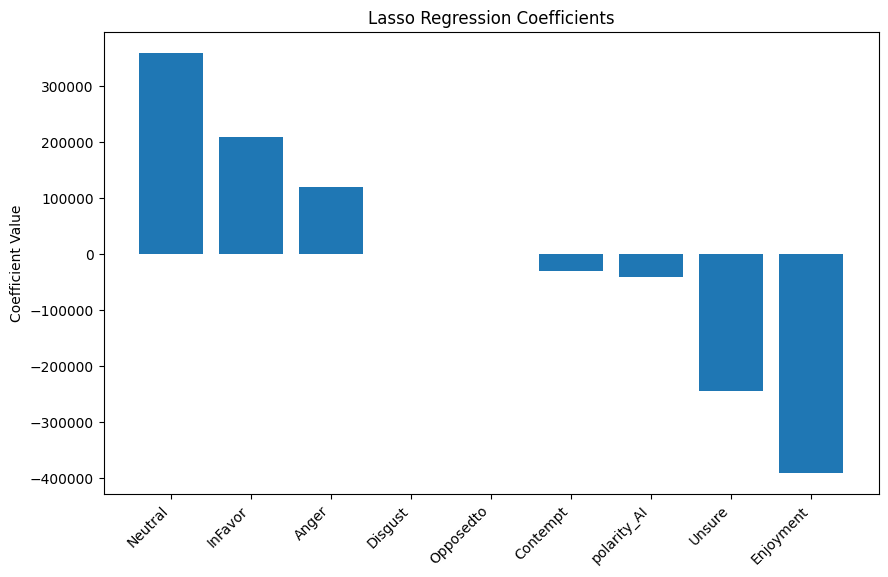

In [31]:
plt.figure(figsize=(10, 6))
plt.bar(coef_df_p["Feature"], coef_df_p["Coefficient"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression Coefficients")
plt.show()


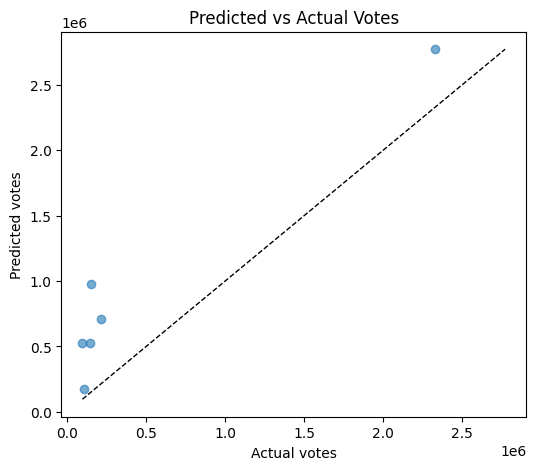

R²: 0.6346923798361885


In [32]:
y_pred = lm_p.predict(X_all_test_p)

plt.figure(figsize=(6, 5))
plt.scatter(y_all_test_p, y_pred_p, alpha=0.6)
lims = [
    min(y_all_test_p.min(), y_pred_p.min()),
    max(y_all_test_p.max(), y_pred_p.max()),
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual votes")
plt.ylabel("Predicted votes")
plt.title("Predicted vs Actual Votes")
plt.show()

r2 = r2_score(y_all_test_p, y_pred_p)
print("R²:", r2)

In [33]:
# Kabataan Partylists
# out of a sample of 1000 tweets,
# 311762	0	0	0	4	4	8	0	0	0.612500

ANGER = 0
CONTEMPT = 0
DISGUST = 0
ENJOYMENT = 4
NEUTRAL = 4
INFAVOR = 8
OPPOSEDTO = 0
UNSURE = 0
POLARITY_AI = 0.612500


sample_df_all = pd.DataFrame(
    [
        [
            ANGER,
            CONTEMPT,
            DISGUST,
            ENJOYMENT,
            NEUTRAL,
            INFAVOR,
            OPPOSEDTO,
            UNSURE,
            POLARITY_AI,
        ]
    ],
    columns=df_partylists_all.columns[1:],
)

sample_scaled = scaler_p.transform(sample_df_all)

predicted_votes_all = lm_p.predict(sample_scaled)

actual_votes = partylist_votes_df.loc["kabataan", "total"]
predicted_votes = predicted_votes_all[0]

comparison_df = pd.DataFrame(
    {
        "Partylist": ["Kabataan"],
        "Actual Votes": [actual_votes],
        "Predicted Votes": [predicted_votes],
        "Difference": [predicted_votes - actual_votes],
    }
)

comparison_df


,Partylist,Actual Votes,Predicted Votes,Difference
0,Kabataan,311762,576429.956902,264667.956902


In [34]:
def model_predict_p(
    lm: Ridge,
    ANGER: int,
    CONTEMPT: int,
    DISGUST: int,
    ENJOYMENT: int,
    NEUTRAL: int,
    INFAVOR: int,
    OPPOSEDTO: int,
    UNSURE: int,
    POLARITY_AI: float,
):
    sample_df_all = pd.DataFrame(
        [
            [
                ANGER,
                CONTEMPT,
                DISGUST,
                ENJOYMENT,
                NEUTRAL,
                INFAVOR,
                OPPOSEDTO,
                UNSURE,
                POLARITY_AI,
            ]
        ],
        columns=df_partylists_all.columns[1:],
    )

    sample_scaled = scaler_p.transform(sample_df_all)

    predicted_votes_all = lm_p.predict(sample_scaled)

    return predicted_votes_all[0]

In [35]:
interact(
    model_predict_p,
    lm=fixed(lm_p),
    ANGER=(0, 200, 1),
    CONTEMPT=(0, 200, 1),
    DISGUST=(0, 200, 1),
    ENJOYMENT=(0, 200, 1),
    NEUTRAL=(0, 200, 1),
    INFAVOR=(0, 200, 1),
    OPPOSEDTO=(0, 200, 1),
    UNSURE=(0, 200, 1),
    POLARITY_AI=(-1.0, 1.0, 0.05),
);

interactive(children=(IntSlider(value=100, description='ANGER', max=200), IntSlider(value=100, description='CO…

# Save models as a pickle file for future use

In [36]:
with open("model_senate.pkl", "wb") as f:
    pickle.dump(lm, f)
with open("scaler_senate.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [37]:
with open("model_partylists.pkl", "wb") as f:
    pickle.dump(lm_p, f)
with open("scaler_partylists.pkl", "wb") as f:
    pickle.dump(scaler_p, f)